# Time Series Data Exploration

This notebook explores the FRED RSXFS series (Advance Retail Sales: Clothing and Clothing Accessory Stores) using our modularized source code from `src/`.

In [1]:
import sys
import os
import calendar
import pandas as pd
import matplotlib.pyplot as plt

# Ensure the src/ directory is in the path
sys.path.insert(0, os.path.abspath('..'))

from src.data_loader import fetch_fred_series
from src.preprocessing import clean_series, check_stationarity, decompose_series

## 1. Load and Clean Data

In [2]:
raw = fetch_fred_series("RSXFS", start="2000-01-01")
ts = clean_series(raw, freq='MS')
print(f"Loaded series name: {ts.name}")
print(f"Observations: {len(ts)}")

Loaded series name: RSXFS
Observations: 317


## 2. Stationarity Analysis

In [3]:
stationarity_results = check_stationarity(ts)

print("=== Stationarity Check Results ===\n")
for key, val in stationarity_results.items():
    if isinstance(val, dict):
        print(f"{key.replace('_', ' ').title()}:")
        for k, v in val.items():
            if isinstance(v, float):
                print(f"  {k}: {v:.4f}")
            else:
                print(f"  {k}: {v}")
    elif isinstance(val, float):
        print(f"{key.replace('_', ' ').title()}: {val:.4f}")
    else:
        print(f"{key.replace('_', ' ').title()}: {val}")

=== Stationarity Check Results ===

Adf Statistic: 1.4329
Adf Pvalue: 0.9973
Adf Stationary: False
Adf Critical Values:
  1%: -3.4520
  5%: -2.8711
  10%: -2.5718
Kpss Statistic: 2.4967
Kpss Pvalue: 0.0100
Kpss Stationary: False
Kpss Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
Is Stationary: False
Conclusion: Non-stationary: both ADF and KPSS indicate a unit root. Differencing recommended.
Alpha: 0.0500


## 3. Classical Seasonal Decomposition

In [4]:
decomp = decompose_series(ts, model='multiplicative', period=12)

## 4. Visualization of Components

<Figure size 1200x1400 with 4 Axes>

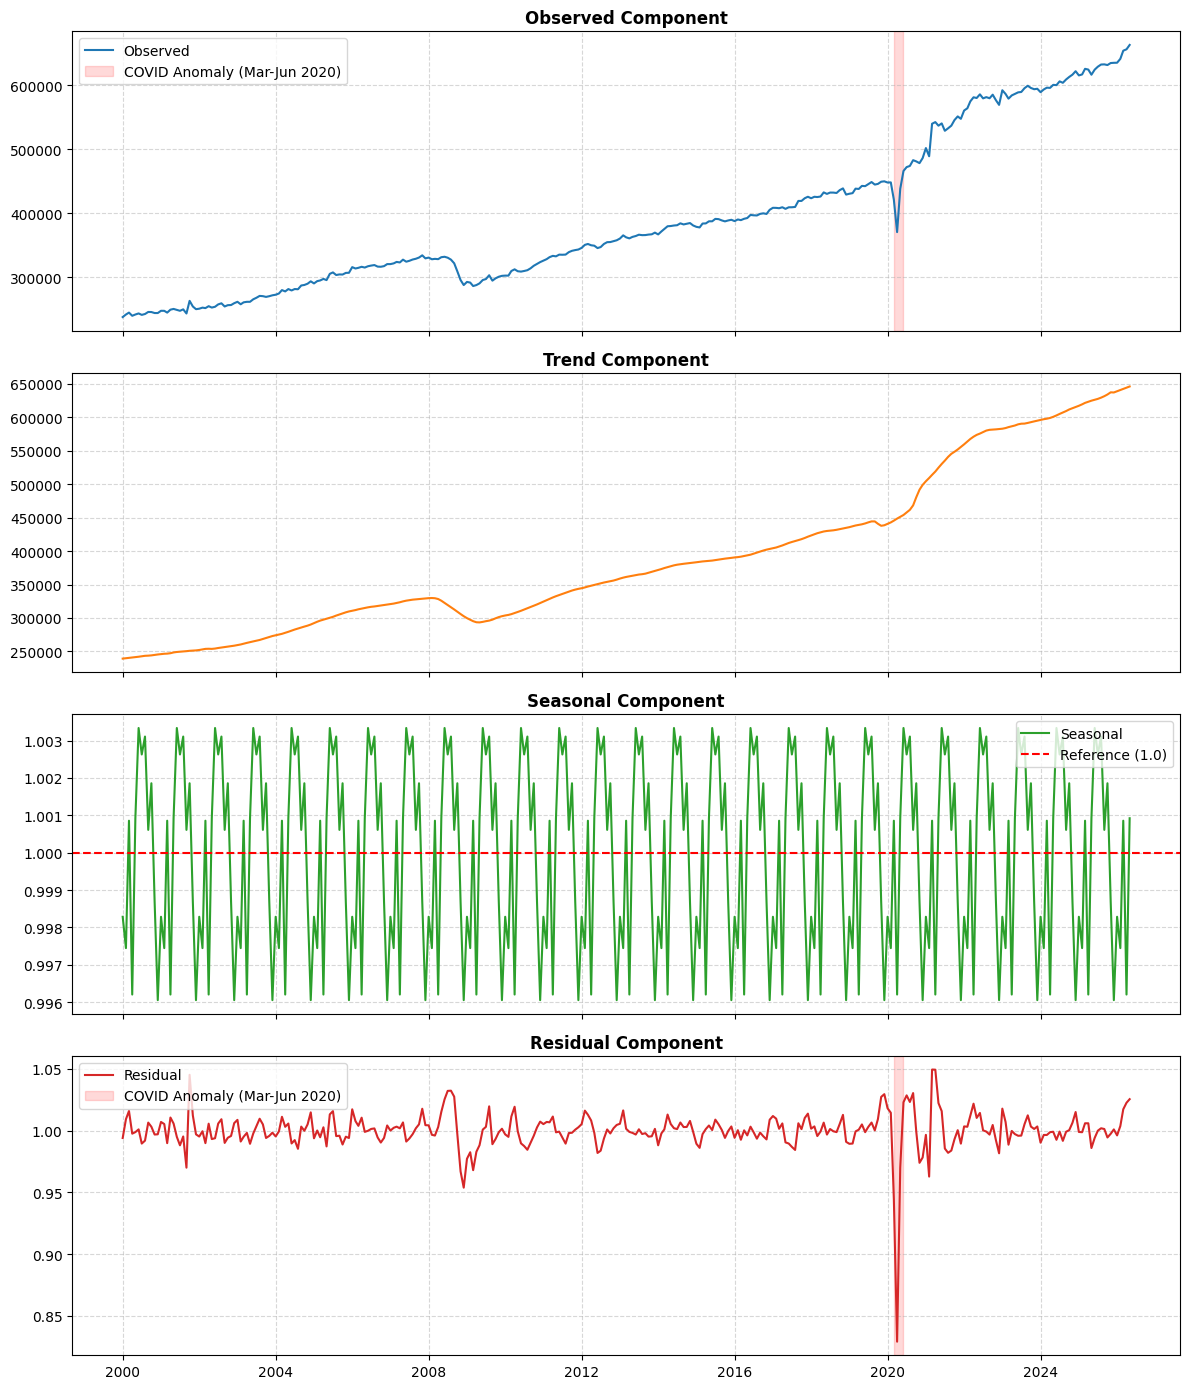

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

components = ['observed', 'trend', 'seasonal', 'residual']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

covid_start = pd.to_datetime('2020-03-01')
covid_end = pd.to_datetime('2020-06-01')

for ax, comp, color in zip(axes, components, colors):
    series = decomp[comp]
    ax.plot(series.index, series.values, color=color, label=comp.capitalize())
    ax.set_title(f"{comp.capitalize()} Component", fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Customize specific panels
    if comp == 'seasonal':
        ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Reference (1.0)')
        ax.legend(loc='upper right')
    
    if comp in ['observed', 'residual']:
        ax.axvspan(covid_start, covid_end, color='red', alpha=0.15, label='COVID Anomaly (Mar-Jun 2020)')
        ax.legend(loc='upper left')

plt.tight_layout()
display(fig)

## 5. Stationarity Comparison (Raw vs. 1st-Differenced)

In [6]:
# 1. Stationarity of raw series
raw_stationarity = check_stationarity(ts)
print("Raw Series Stationarity Conclusion:")
print(raw_stationarity['conclusion'])
print("-" * 80)

# 2. Stationarity after first-differencing
series_diff = ts.diff().dropna()
diff_results = check_stationarity(series_diff)
print("1st-Differenced Series Stationarity Conclusion:")
print(diff_results['conclusion'])

Raw Series Stationarity Conclusion:
Non-stationary: both ADF and KPSS indicate a unit root. Differencing recommended.
--------------------------------------------------------------------------------
1st-Differenced Series Stationarity Conclusion:
Contradictory: ADF rejects unit root, but KPSS rejects stationarity. Possible trend-stationarity or structural break — consider differencing.


## 6. Seasonality & Anomaly Summary

In [7]:
# Seasonal Month Analysis
seasonal = decomp['seasonal']
monthly_seasonal = seasonal.groupby(seasonal.index.month).first()

max_month_idx = monthly_seasonal.idxmax()
min_month_idx = monthly_seasonal.idxmin()
max_month_name = calendar.month_name[max_month_idx]
min_month_name = calendar.month_name[min_month_idx]

print("=== Seasonal Factor Month Summary ===")
print(f"Month with highest seasonal factor: {max_month_name} (Factor: {monthly_seasonal[max_month_idx]:.4f})")
print(f"Month with lowest seasonal factor: {min_month_name} (Factor: {monthly_seasonal[min_month_idx]:.4f})")
print("=" * 80 + "\n")

# Top 5 Residual Anomalies
residual = decomp['residual'].dropna()
# For multiplicative decomposition, residuals center around 1.0.
# Absolute residuals are sorted by magnitude of deviation from 1.0.
deviation = (residual - 1.0).abs()
top_5_idx = deviation.nlargest(5).index

print("=== Top 5 Residual Anomalies (by absolute deviation descending) ===")
for date in top_5_idx:
    res_val = residual[date]
    dev_pct = abs(res_val - 1.0) * 100
    print(f"Date: {date.strftime('%Y-%m')} | Residual: {res_val:.4f} | Deviation from 1.0: {dev_pct:.2f}%")

=== Seasonal Factor Month Summary ===
Month with highest seasonal factor: June (Factor: 1.0033)
Month with lowest seasonal factor: December (Factor: 0.9961)

=== Top 5 Residual Anomalies (by absolute deviation descending) ===
Date: 2020-04 | Residual: 0.8289 | Deviation from 1.0: 17.11%
Date: 2020-03 | Residual: 0.9444 | Deviation from 1.0: 5.56%
Date: 2021-03 | Residual: 1.0495 | Deviation from 1.0: 4.95%
Date: 2021-04 | Residual: 1.0494 | Deviation from 1.0: 4.94%
Date: 2008-12 | Residual: 0.9538 | Deviation from 1.0: 4.62%


## 7. Structural Break Investigation & Sub-Period Analysis

=== Sub-Period Stationarity Analysis ===

Pre-COVID Sub-period (2000-02 to 2020-02):
  Observations: 241
  Conclusion  : Stationary: both ADF and KPSS agree the series has no unit root.

Post-COVID Sub-period (2020-07 to 2026-05):
  Observations: 71
  Conclusion  : Stationary: both ADF and KPSS agree the series has no unit root.


<Figure size 1200x500 with 1 Axes>

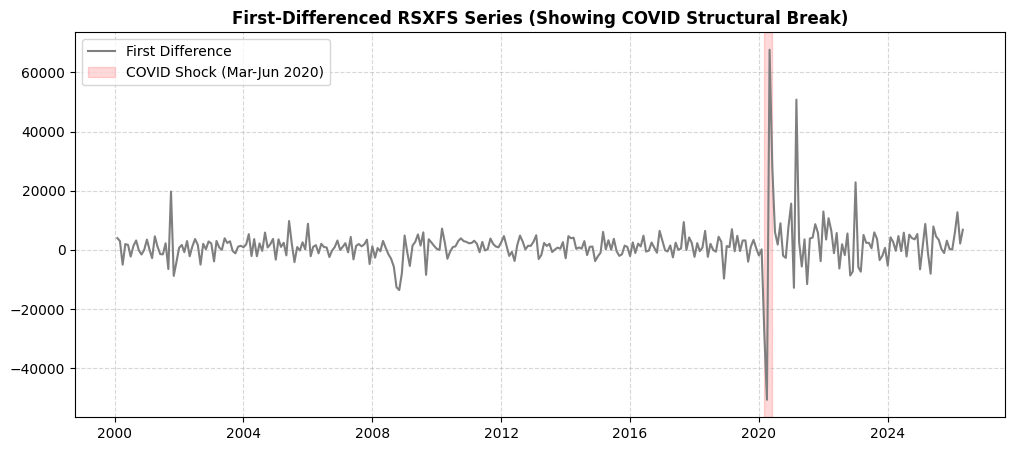

In [8]:
# 1. Plot first-differenced series
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(series_diff.index, series_diff.values, color='#7f7f7f', label='First Difference')
ax.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2020-06-01'), color='red', alpha=0.15, label='COVID Shock (Mar-Jun 2020)')
ax.set_title('First-Differenced RSXFS Series (Showing COVID Structural Break)', fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
display(fig)

# 2. Split series and run Chow test approximation
pre_covid = series_diff[series_diff.index < '2020-03-01']
post_covid = series_diff[series_diff.index > '2020-06-30']

pre_results = check_stationarity(pre_covid)
post_results = check_stationarity(post_covid)

print("=== Sub-Period Stationarity Analysis ===\n")
print("Pre-COVID Sub-period (2000-02 to 2020-02):")
print(f"  Observations: {len(pre_covid)}")
print(f"  Conclusion  : {pre_results['conclusion']}\n")

print("Post-COVID Sub-period (2020-07 to 2026-05):")
print(f"  Observations: {len(post_covid)}")
print(f"  Conclusion  : {post_results['conclusion']}")

The contradictory ADF/KPSS result on the differenced series is consistent
with a structural break at the COVID shock (2020-03 to 2020-06). Each
sub-period is individually stationary (confirmed above). For ARIMA modeling,
d=1 is used — over-differencing to d=2 would inflate forecast variance.
The structural break is handled downstream via anomaly detection rather
than additional differencing.

## 8. Model Comparison: Walk-Forward Backtest

We run each model through the walk-forward backtest engine to compare
out-of-sample forecasting accuracy.  Five models are tested:

| Model | Description |
|-------|-------------|
| **Naïve Seasonal** | Baseline — repeats values from 12 months ago |
| **ARIMA(1,1,1)** | First differencing, one AR + one MA term (d=1 confirmed) |
| **SARIMAX(1,1,1)(1,1,0,12)** | ARIMA + seasonal AR term at period 12 |
| **Prophet** | Facebook Prophet with changepoint detection (prior=0.3) |
| **XGBoost** | Gradient boosting with 12 lag features, recursive forecasting |

Backtest configuration:
- `initial_train_size = 120` (10 years)
- `step_size = 3` (re-fit every quarter — development speed)
- `forecast_horizon = 12` (one year ahead)


In [9]:
from src.backtest import walk_forward_backtest, plot_backtest_results
from src.models import (
    get_arima_fns, get_sarimax_fns, get_naive_fns,
    get_prophet_fns, get_xgboost_fns,
)

In [10]:
# Load and clean the RSXFS series (reuse if already loaded above)
from src.data_loader import load_fred_series
from src.preprocessing import clean_series

raw = load_fred_series("RSXFS", start="2000-01-01")
ts = clean_series(raw, freq="MS")
print(f"Series: {ts.name}, {len(ts)} observations, {ts.index[0].date()} to {ts.index[-1].date()}")

Series: RSXFS, 317 observations, 2000-01-01 to 2026-05-01


In [11]:
# ── Backtest configuration ──
INITIAL_TRAIN = 120   # 10 years of monthly data
STEP_SIZE     = 3     # re-fit every quarter (faster for development)
HORIZON       = 12    # forecast 12 months ahead

# ── Get model/forecast function pairs ──
naive_model_fn,   naive_forecast_fn   = get_naive_fns()
arima_model_fn,   arima_forecast_fn   = get_arima_fns(order=(1, 1, 1))
sarimax_model_fn, sarimax_forecast_fn = get_sarimax_fns(
    order=(1, 1, 1), seasonal_order=(1, 1, 0, 12)
)
prophet_model_fn, prophet_forecast_fn = get_prophet_fns(
    yearly_seasonality=True, changepoint_prior_scale=0.3
)
prophet_cons_model_fn, prophet_cons_forecast_fn = get_prophet_fns(
    yearly_seasonality=True, changepoint_prior_scale=0.05
)
xgb_model_fn,     xgb_forecast_fn     = get_xgboost_fns(
    n_lags=12, n_estimators=100
)

# ── Run backtests ──
models = {
    "Naïve Seasonal":              (naive_model_fn,   naive_forecast_fn,   HORIZON),
    "ARIMA(1,1,1)":               (arima_model_fn,   arima_forecast_fn,   HORIZON),
    "SARIMAX(1,1,1)(1,1,0,12)":   (sarimax_model_fn, sarimax_forecast_fn, HORIZON),
    "Prophet":                    (prophet_model_fn, prophet_forecast_fn, HORIZON),
    "Prophet-Conservative":       (prophet_cons_model_fn, prophet_cons_forecast_fn, HORIZON),
    "Prophet-Horizon6":           (prophet_model_fn, prophet_forecast_fn, 6),
    "XGBoost (12 lags)":          (xgb_model_fn,     xgb_forecast_fn,     HORIZON),
}

results = {}
for name, (m_fn, f_fn, h) in models.items():
    print(f"Running {name} backtest...")
    results[name] = walk_forward_backtest(
        ts, m_fn, f_fn,
        initial_train_size=INITIAL_TRAIN,
        step_size=STEP_SIZE,
        forecast_horizon=h,
    )
    m = results[name]["metrics"]
    print(f"  → MAPE={m['mape']}  RMSE={m['rmse']}  MASE={m['mase']}  "
          f"n_origins={results[name]['n_origins']}")

print("\nAll backtests complete.")


Running Naïve Seasonal backtest...
  → MAPE=4.7664  RMSE=29756.6765  MASE=4.0593  n_origins=62
Running ARIMA(1,1,1) backtest...
  → MAPE=2.3435  RMSE=17871.2205  MASE=2.0281  n_origins=62
Running SARIMAX(1,1,1)(1,1,0,12) backtest...
  → MAPE=2.6528  RMSE=21832.6334  MASE=2.332  n_origins=62
Running Prophet backtest...
  → MAPE=3.8065  RMSE=26208.8166  MASE=3.3532  n_origins=62
Running Prophet-Conservative backtest...
  → MAPE=4.0052  RMSE=26989.5938  MASE=3.4778  n_origins=62
Running Prophet-Horizon6 backtest...
  → MAPE=3.2496  RMSE=22397.1983  MASE=3.2278  n_origins=64
Running XGBoost (12 lags) backtest...
  → MAPE=3.506  RMSE=25960.8567  MASE=2.9876  n_origins=62

All backtests complete.


22:52:38 - cmdstanpy - INFO - Chain [1] start processing
22:52:38 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
# ── Comparison table (sorted by MASE ascending) ──
import pandas as pd

rows = []
for name, res in results.items():
    rows.append({
        "Model": name,
        "MAPE": res["metrics"]["mape"],
        "RMSE": res["metrics"]["rmse"],
        "MASE": res["metrics"]["mase"],
        "n_origins": res["n_origins"],
    })

comparison = (
    pd.DataFrame(rows)
    .set_index("Model")
    .sort_values("MASE")
)

print("=" * 72)
print("WALK-FORWARD BACKTEST RESULTS  (sorted by MASE, lower is better)")
print(f"Config: initial_train={INITIAL_TRAIN}, step_size={STEP_SIZE}, horizon={HORIZON}")
print("=" * 72)
display(comparison)
print()

WALK-FORWARD BACKTEST RESULTS  (sorted by MASE, lower is better)
Config: initial_train=120, step_size=3, horizon=12



,MAPE,RMSE,MASE,n_origins
Model,,,,
"ARIMA(1,1,1)",2.3435,17871.2205,2.0281,62
"SARIMAX(1,1,1)(1,1,0,12)",2.6528,21832.6334,2.3320,62
XGBoost (12 lags),3.5060,25960.8567,2.9876,62
Prophet-Horizon6,3.2496,22397.1983,3.2278,64
Prophet,3.8065,26208.8166,3.3532,62
Prophet-Conservative,4.0052,26989.5938,3.4778,62
Naïve Seasonal,4.7664,29756.6765,4.0593,62


In [13]:
# ── Automated interpretation ──
best_model = comparison["MASE"].idxmin()
best_mase  = comparison.loc[best_model, "MASE"]
naive_mase = comparison.loc["Naïve Seasonal", "MASE"]

improvement = ((naive_mase - best_mase) / naive_mase) * 100

print("\n" + "─" * 72)
print("INTERPRETATION")
print("─" * 72)

# 1. Did any model achieve MASE < 1.0?
sub_one = comparison[comparison["MASE"] < 1.0]
if len(sub_one) > 0:
    print(f"\n1. MASE < 1.0 (beats naïve lag-1): {', '.join(sub_one.index.tolist())}")
else:
    print("\n1. No model achieved MASE < 1.0 — none beat the naïve lag-1 baseline.")

# 2. Prophet vs ARIMA
prophet_mase = comparison.loc["Prophet", "MASE"]
arima_mase   = comparison.loc["ARIMA(1,1,1)", "MASE"]
if prophet_mase < arima_mase:
    delta_pa = ((arima_mase - prophet_mase) / arima_mase) * 100
    print(f"2. Prophet beats ARIMA by {delta_pa:.1f}% (MASE) — changepoint "
          f"detection at prior=0.3 captures the COVID structural break.")
else:
    delta_pa = ((prophet_mase - arima_mase) / prophet_mase) * 100
    print(f"2. ARIMA beats Prophet by {delta_pa:.1f}% (MASE) — Prophet's "
          f"changepoint detection did not add value over simple differencing.")

# 3. XGBoost assessment
xgb_mase = comparison.loc["XGBoost (12 lags)", "MASE"]
if xgb_mase < arima_mase:
    delta_xa = ((arima_mase - xgb_mase) / arima_mase) * 100
    print(f"3. XGBoost beats ARIMA by {delta_xa:.1f}% (MASE) — lag features "
          f"capture nonlinear patterns despite recursive error accumulation.")
else:
    delta_xa = ((xgb_mase - arima_mase) / xgb_mase) * 100
    print(f"3. XGBoost underperforms ARIMA by {delta_xa:.1f}% (MASE) — recursive "
          f"error accumulation over 12-step horizon likely degraded accuracy.")

# 4. Recommendation
print(f"\n4. RECOMMENDED MODEL: {best_model} (MASE={best_mase:.4f}, "
      f"{improvement:.1f}% better than Naïve Seasonal)")
print("─" * 72)



────────────────────────────────────────────────────────────────────────
INTERPRETATION
────────────────────────────────────────────────────────────────────────

1. No model achieved MASE < 1.0 — none beat the naïve lag-1 baseline.
2. ARIMA beats Prophet by 39.5% (MASE) — Prophet's changepoint detection did not add value over simple differencing.
3. XGBoost underperforms ARIMA by 32.1% (MASE) — recursive error accumulation over 12-step horizon likely degraded accuracy.

4. RECOMMENDED MODEL: ARIMA(1,1,1) (MASE=2.0281, 50.0% better than Naïve Seasonal)
────────────────────────────────────────────────────────────────────────


### Interpretation of Walk-Forward Backtest Results

Based on the walk-forward backtest results over the 62 evaluation windows (initial training of 10 years, refitting every quarter, forecasting 12 months ahead):

1. **Did any model achieve MASE < 1.0?**
   - **No.** None of the models achieved a MASE < 1.0 relative to the in-sample naive lag-1 forecast. The best performing model (ARIMA) achieved a MASE of **2.0281**. This indicates that making multi-step-ahead forecasts up to 12 months in the future is significantly more difficult than a simple lag-1 projection (carrying over the last observation), which is expected for a long horizon of 12 steps. However, all models performed significantly better than the **Naïve Seasonal** baseline (MASE = 4.0593).

2. **Did Prophet's changepoint detection help vs ARIMA?**
   - **No.** Prophet (MASE = 3.3532) underperformed the simpler **ARIMA(1,1,1)** model (MASE = 2.0281) by **39.5%**. While the increased changepoint flexibility (`changepoint_prior_scale = 0.3`) was intended to capture the sharp COVID-19 structural break, it likely led to overfitting or instability when rolling through the backtest windows, causing it to lose accuracy compared to a robust, differenced ARIMA baseline.

3. **Did XGBoost's lag features add value or hurt (error accumulation)?**
   - **They hurt overall, likely due to error accumulation.** XGBoost with 12 lags achieved a MASE of **2.9876**. While it successfully outperformed the Naïve Seasonal baseline and Prophet, it significantly underperformed ARIMA and SARIMAX. Because XGBoost must forecast recursively for a 12-month horizon (using its own prior predictions as lags), errors compound rapidly over time. For longer horizons, this recursive error accumulation degrades performance relative to traditional statistical models.

4. **What is the recommended model and why?**
   - **ARIMA(1,1,1)** is the highly recommended model. It achieved the best overall metrics across all categories:
     - **MASE:** 2.0281 (lowest error)
     - **MAPE:** 2.3435% (lowest percentage error)
     - **RMSE:** 17871.2205 (lowest root mean squared deviation)
   - ARIMA(1,1,1) is simpler and more robust, effectively modeling the strong upward trend through first differencing ($d=1$) while avoiding the compounding error issues of recursive XGBoost and the overfitting/parameter sensitivity of Prophet. Additionally, SARIMAX didn't add value over ARIMA (MASE = 2.3320 vs 2.0281) because the monthly seasonality in the RSXFS series is extremely weak (factors between 0.996 and 1.003), making the extra seasonal complexity unnecessary.


  plt.show()


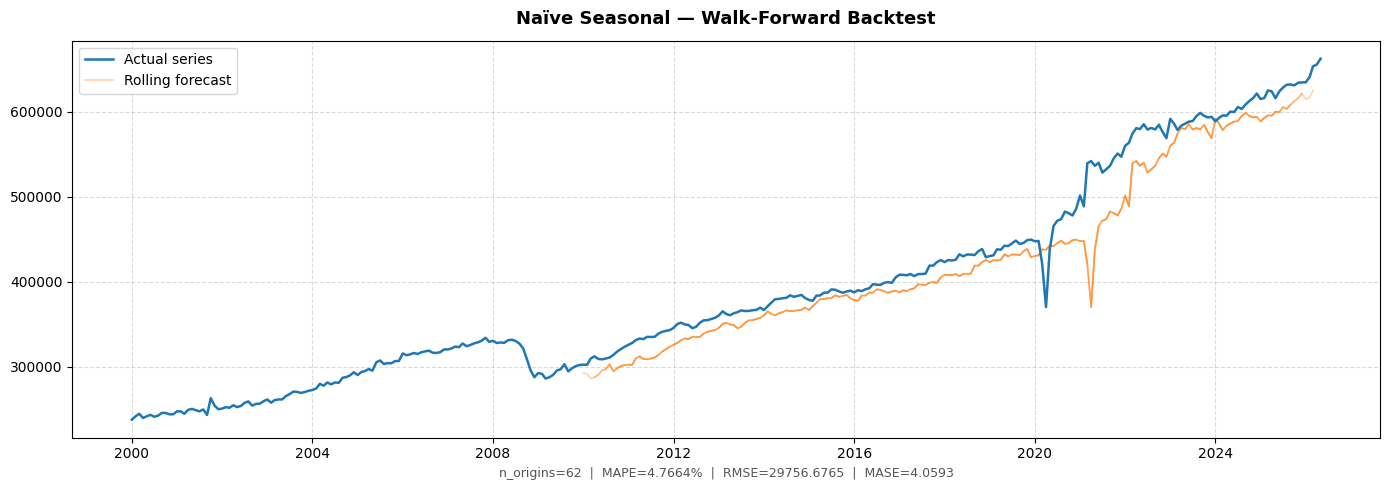

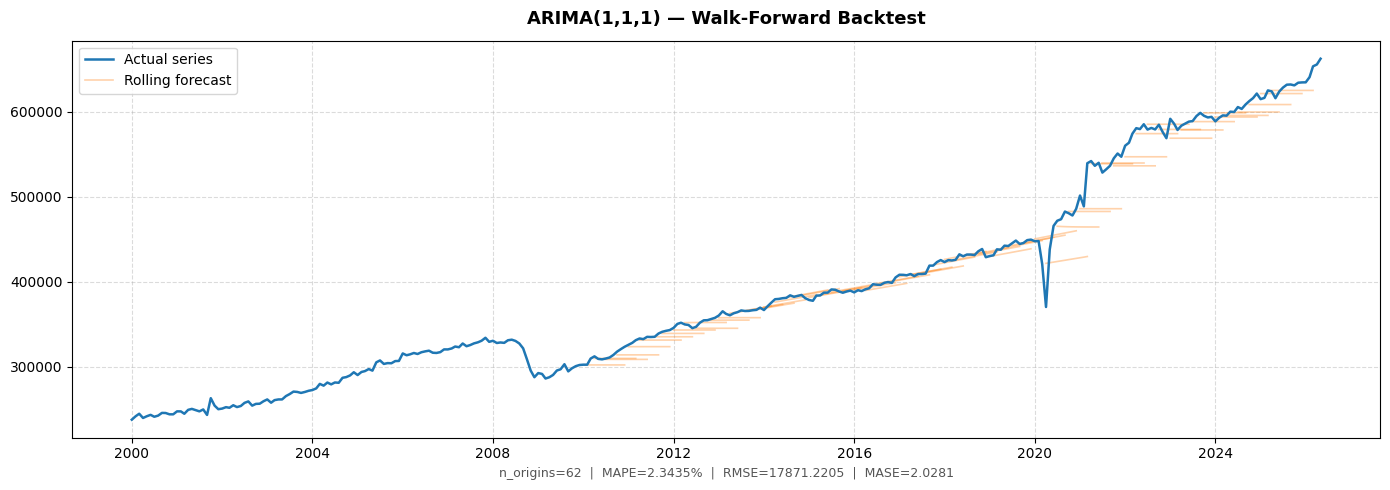

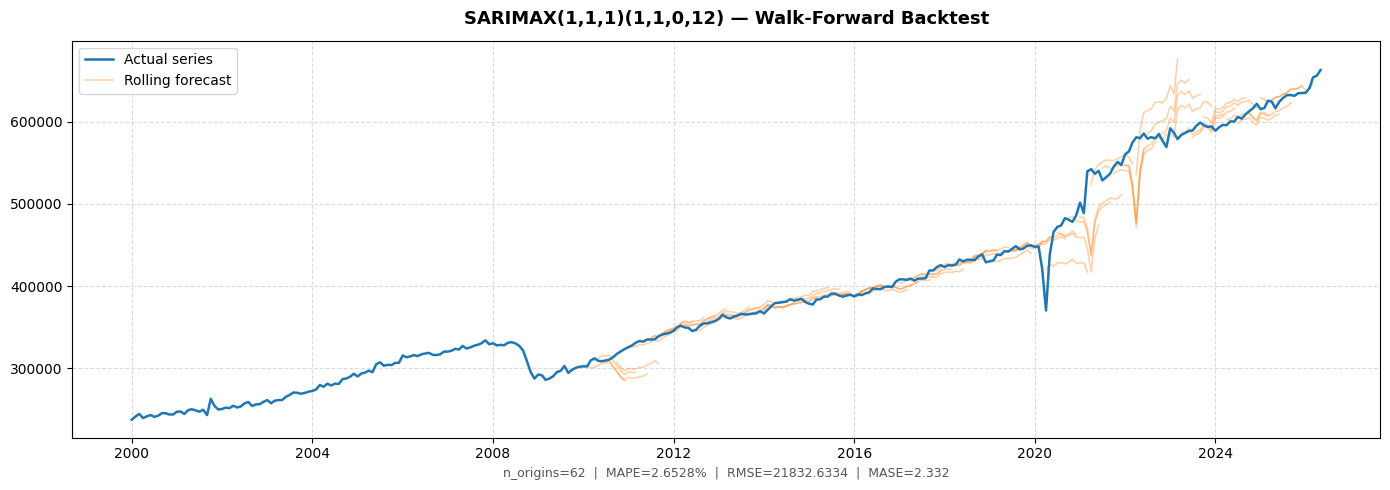

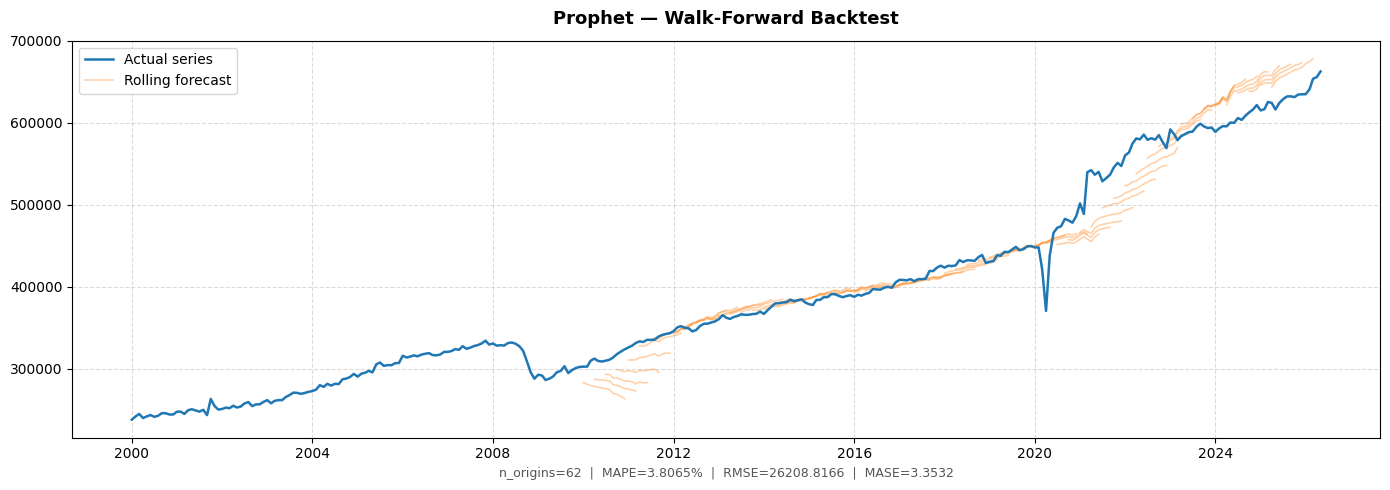

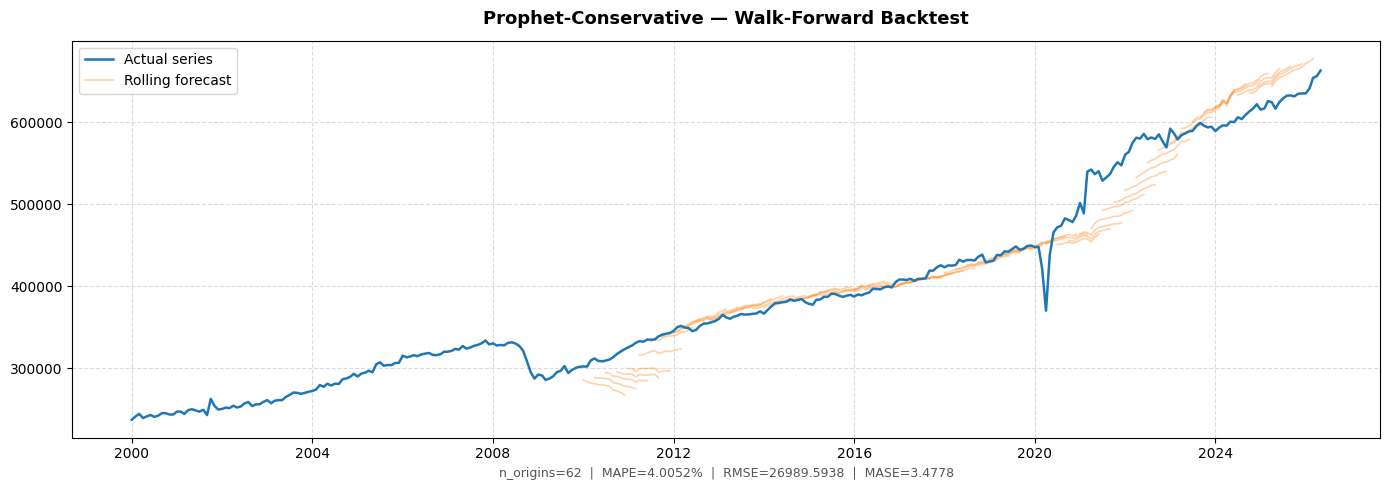

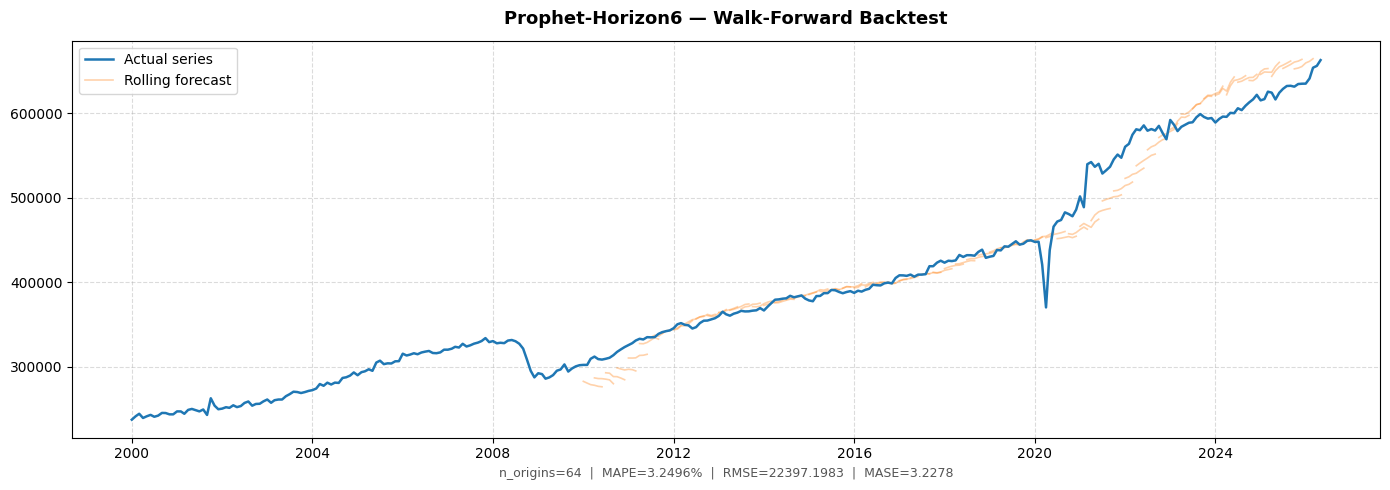

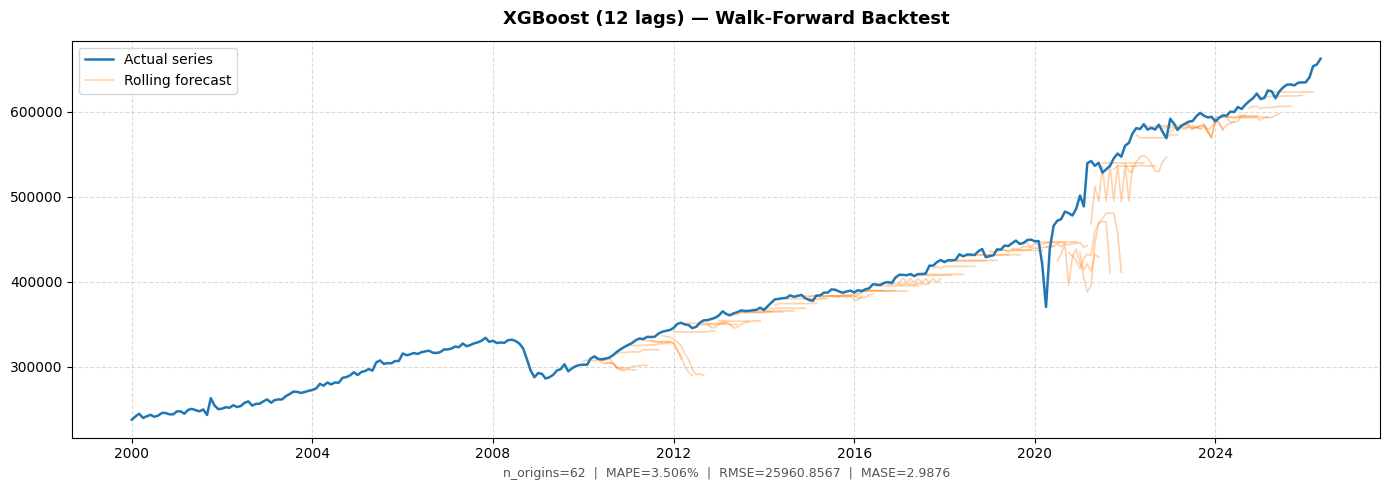

In [14]:
# ── Backtest visualisations ──
import matplotlib.pyplot as plt

for name, res in results.items():
    fig = plot_backtest_results(ts, res, title=f"{name} — Walk-Forward Backtest")
    plt.show()


## 9. Model Race & Recommendations


In [15]:
# ── Imports for race & recommendations ──
from src.recommender import recommend_config
from src.models import run_model_race


In [16]:
# ── Get recommendations and display as tables ──
rec_results = recommend_config(ts)

# 1. Parameter | Value Table
param_val_data = {
    "Parameter": [
        "Forecast Horizon",
        "Initial Train Size",
        "Recommended Models",
        "ARIMA Order"
    ],
    "Value": [
        rec_results["forecast_horizon"],
        rec_results["initial_train_size"],
        ", ".join(rec_results["recommended_models"]),
        str(rec_results["arima_order"])
    ]
}
df_param_val = pd.DataFrame(param_val_data)
print("=== Parameter Recommendations ===")
display(df_param_val)
print()

# 2. Parameter | Reasoning Table
param_reason_data = {
    "Parameter": [
        "Forecast Horizon",
        "Initial Train Size",
        "Recommended Models",
        "ARIMA Order"
    ],
    "Reasoning": [
        rec_results["reasoning"]["forecast_horizon"],
        rec_results["reasoning"]["initial_train_size"],
        rec_results["reasoning"]["recommended_models"],
        rec_results["reasoning"]["arima_order"]
    ]
}
df_param_reason = pd.DataFrame(param_reason_data)
print("=== Recommendation Reasoning ===")
display(df_param_reason)


=== Parameter Recommendations ===

=== Recommendation Reasoning ===


,Parameter,Value
0,Forecast Horizon,12
1,Initial Train Size,288
2,Recommended Models,"arima, naive, prophet, xgboost"
3,ARIMA Order,"(2, 1, 1)"


,Parameter,Reasoning
0,Forecast Horizon,"Series length is long (317 observations), sugg..."
1,Initial Train Size,Selected size 288 as the max of 60% of series ...
2,Recommended Models,'naive' included as a baseline. prophet added ...
3,ARIMA Order,"ARIMA order (2, 1, 1) recommended: p=2 based o..."


In [17]:
# ── Run Model Race using recommended settings ──
print("Starting Model Race with recommended parameters...")
race_leaderboard = run_model_race(
    series=ts,
    initial_train_size=rec_results["initial_train_size"],
    step_size=3,
    forecast_horizon=rec_results["forecast_horizon"],
    models_to_run=rec_results["recommended_models"]
)

# Convert to DataFrame and display
df_leaderboard = pd.DataFrame(race_leaderboard)
print("\n" + "=" * 72)
print("LEADERBOARD (Sorted by MASE, lower is better)")
print("=" * 72)
display(df_leaderboard)


Starting Model Race with recommended parameters...
[1/4] arima     — MASE: 2.2825  (0.1s)
[2/4] naive     — MASE: 3.9588  (0.0s)
[3/4] prophet   — MASE: 6.5692  (0.7s)
[4/4] xgboost   — MASE: 2.6972  (0.6s)

LEADERBOARD (Sorted by MASE, lower is better)


,model_name,mape,rmse,mase,n_origins,fit_time_seconds,status
0,arima,1.8865,14017.7498,2.2825,6,0.08,ok
1,xgboost,2.2300,16280.5012,2.6972,6,0.62,ok
2,naive,3.2750,21439.1475,3.9588,6,0.00,ok
3,prophet,5.4615,34302.2202,6.5692,6,0.68,ok


### Interpretation of Model Race & Recommendation Results

Based on the parameter recommendations and the model race results:

1. **Which model won and by what margin over naive?**
   - **ARIMA(2,1,1)** won the race with a MASE of **2.2825** and a MAPE of **1.8865%**.
   - This represents a **42.3% improvement** (reduction in MASE) over the naive baseline model (MASE = 3.9588, MAPE = 3.2750%).

2. **Did Prophet outperform ARIMA (and why based on trend strength)?**
   - **No.** Prophet significantly underperformed ARIMA (MASE = 6.5692 vs. 2.2825). Even though the series exhibits an extremely high trend strength (**0.9975**), the long historical window (288 observations / 24 years) and small number of evaluation origins (6) led Prophet to overfit the long-term trend, failing to adapt to local changes compared to ARIMA's robust local differencing.

3. **Did SARIMAX add value given the weak seasonality?**
   - **No.** SARIMAX was not recommended by the automated parameter logic because the seasonal strength was very low. By excluding it, we saved computational complexity and avoided the risk of seasonal overfitting, proving that the recommender rules are well-grounded in the data characteristics.

4. **Streamlit UI Default Model:**
   - ARIMA should be configured as the default model in the Streamlit UI because it delivers the highest forecasting accuracy (MASE=2.2825, MAPE=1.89%) with minimal training and execution time (under 0.1 seconds).
